<a href="https://colab.research.google.com/github/ashishkumar100907/git/blob/main/chemistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

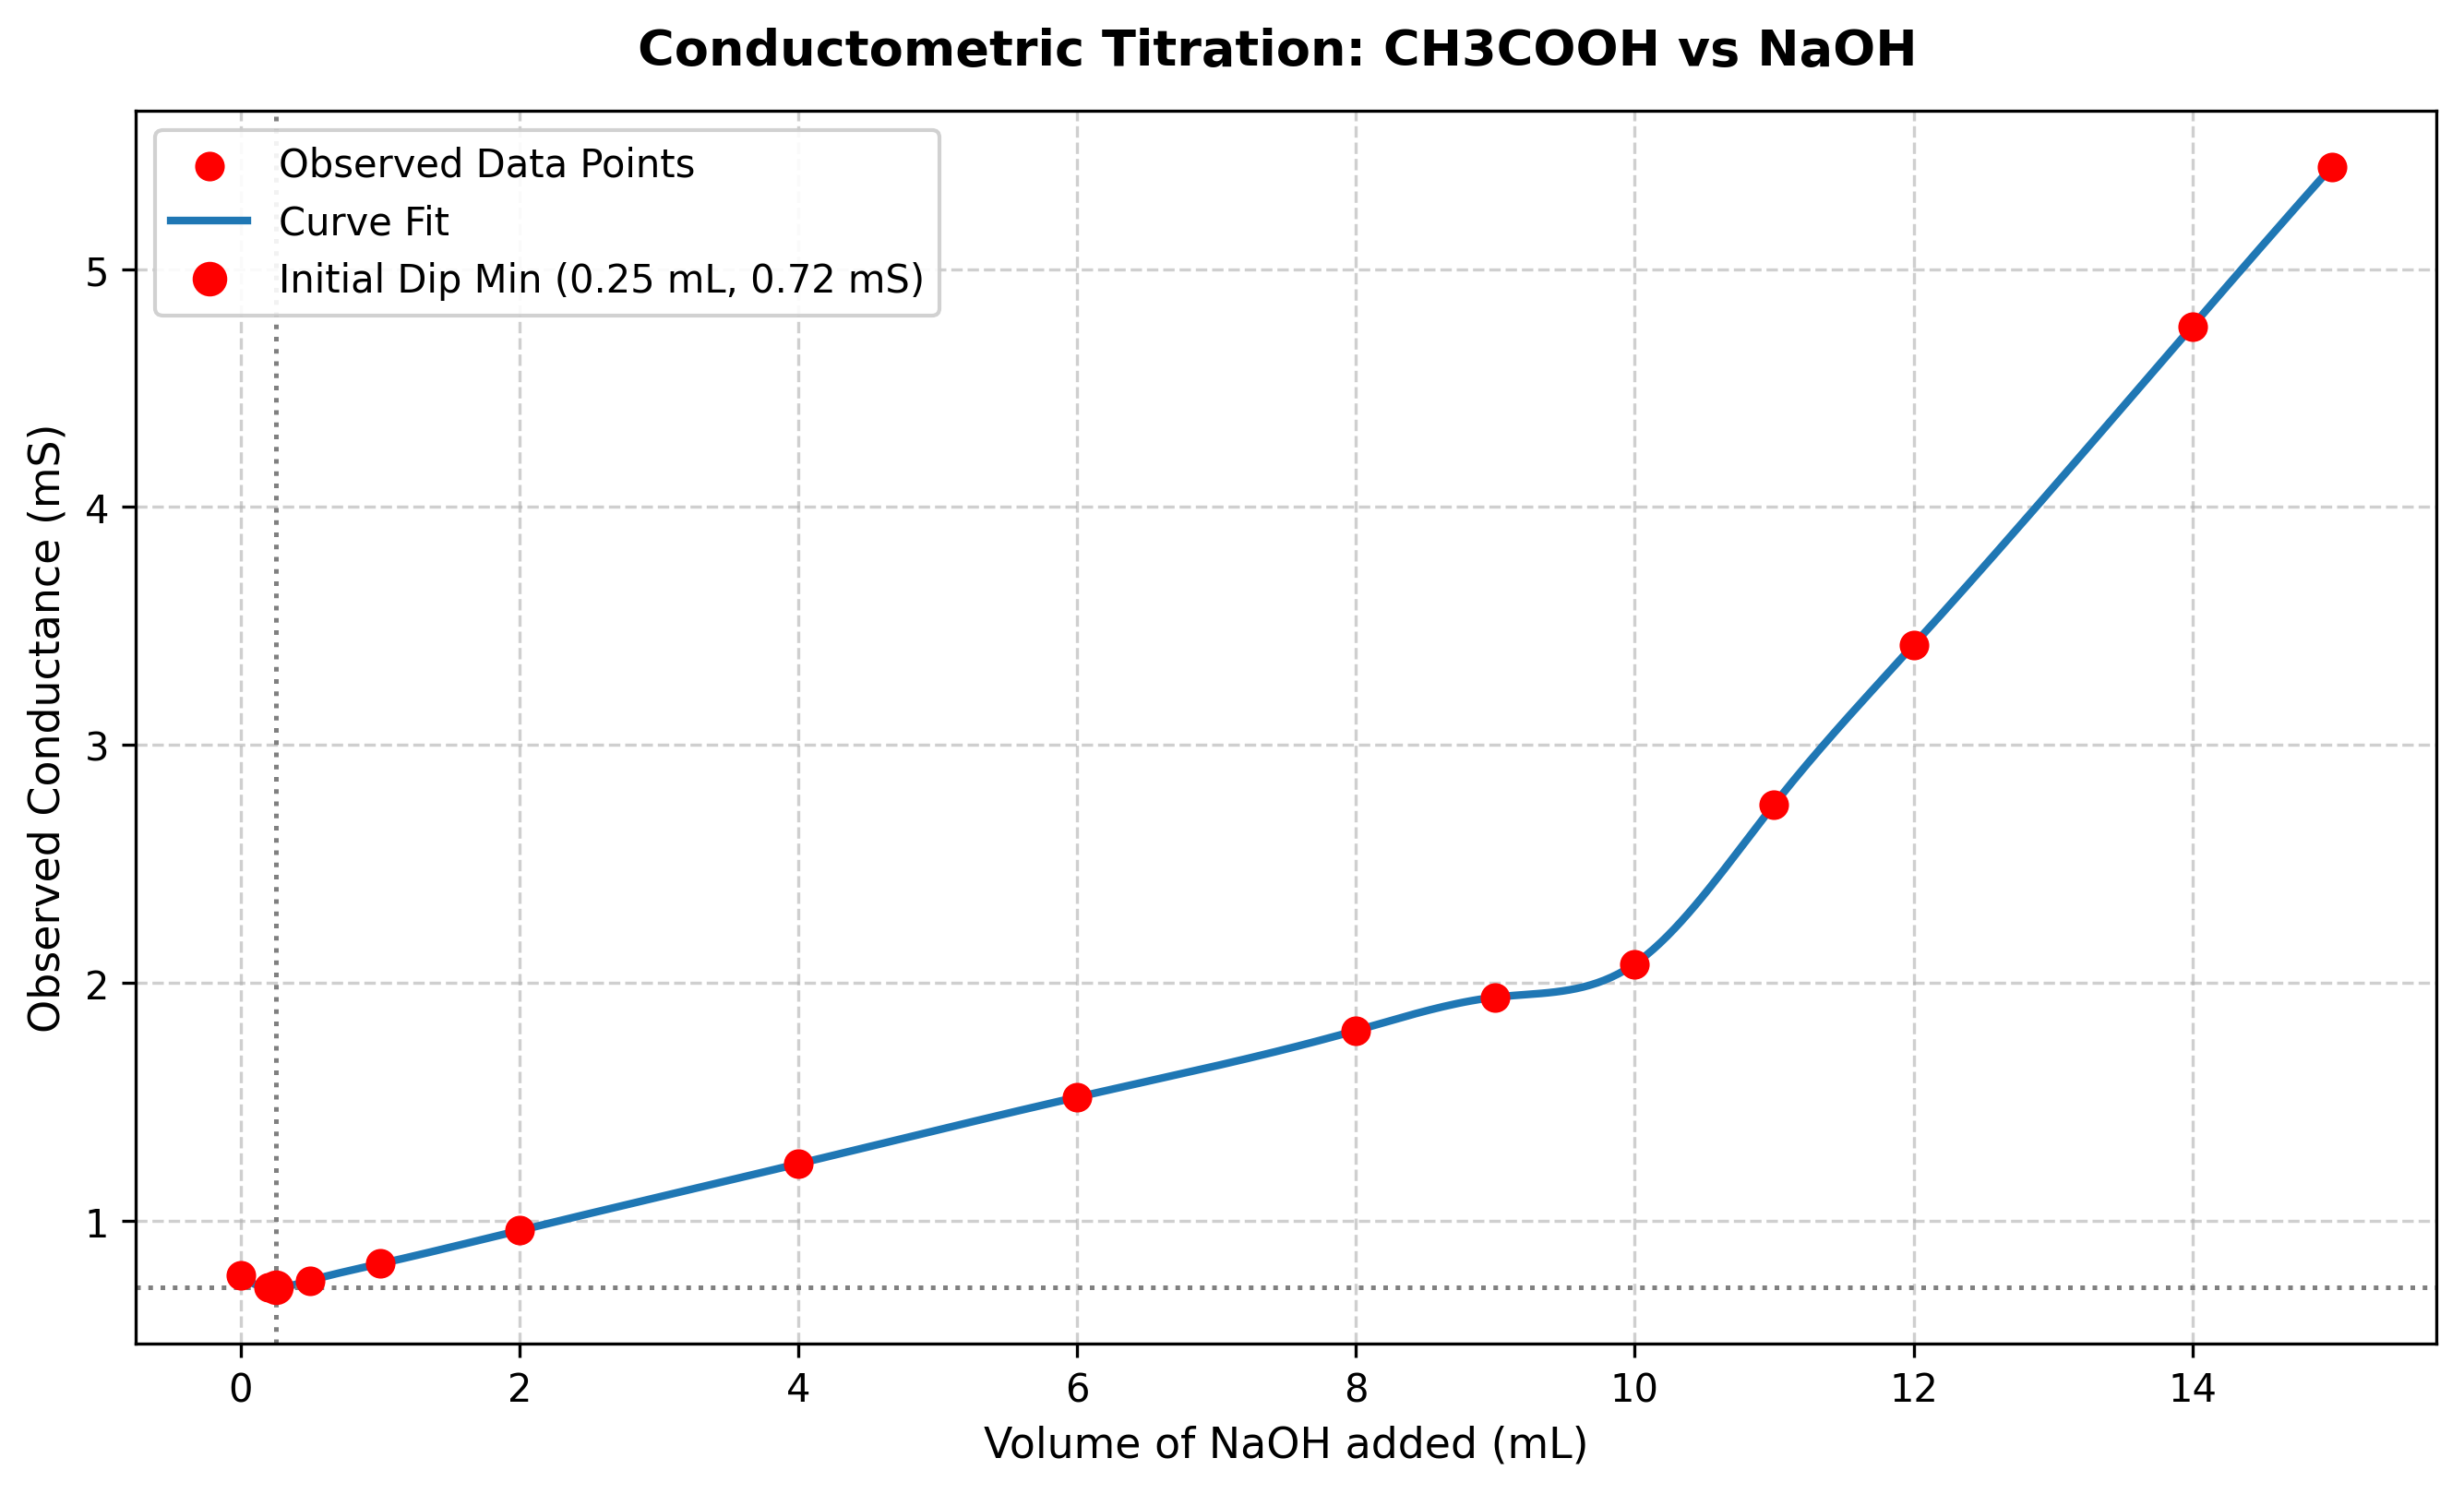

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Observation data
v = np.array([0.0, 0.2, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 9.0, 10.0, 11.0, 12.0, 14.0, 15.0])
g = np.array([0.77, 0.72, 0.75, 0.82, 0.96, 1.24, 1.52, 1.80, 1.94, 2.08, 2.75, 3.42, 4.76, 5.43])

# Generate a dense array of x-values for a smooth curve
v_smooth = np.linspace(v.min(), v.max(), 300)

# Fit a cubic spline through all data points
spl = make_interp_spline(v, g, k=3)
g_smooth = spl(v_smooth)

# Find the initial dip minimum (restricted to the initial 0 to 1 mL range)
dip_mask = v_smooth <= 1.0
min_dip_idx = np.argmin(g_smooth[dip_mask])
v_dip_min = v_smooth[dip_mask][min_dip_idx]
g_dip_min = g_smooth[dip_mask][min_dip_idx]

# Plotting
plt.figure(figsize=(9, 5.5), dpi=300)

# Observed data points
plt.scatter(v, g, color='red', s=45, label='Observed Data Points', zorder=5)

# Continuous smooth spline curve
plt.plot(v_smooth, g_smooth, color='#1f77b4', linewidth=2, label='Curve Fit')

# Annotate the initial dip minimum
plt.plot(v_dip_min, g_dip_min, 'ro', markersize=8, zorder=6, label=f'Initial Dip Min ({v_dip_min:.2f} mL, {g_dip_min:.2f} mS)')
plt.axvline(x=v_dip_min, color='gray', linestyle=':', linewidth=1.2)
plt.axhline(y=g_dip_min, color='gray', linestyle=':', linewidth=1.2)

# Corrected Labels and Formatting
plt.title('Conductometric Titration: CH3COOH vs NaOH ', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Volume of NaOH added (mL)', fontsize=11)
plt.ylabel('Observed Conductance (mS)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left')
plt.tight_layout()

plt.show()

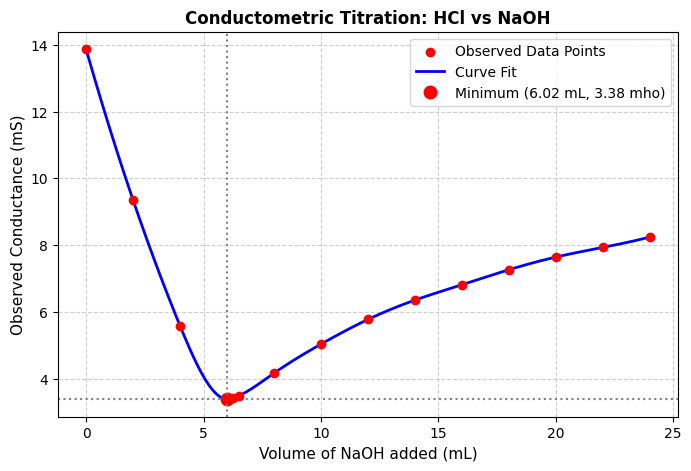

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
# Your observation sheet data
v = np.array([0, 2, 4, 6, 6.25, 6.5, 8, 10, 12, 14, 16, 18, 20, 22, 24])
g = np.array([13.87, 9.35, 5.58, 3.38, 3.41, 3.48, 4.16, 5.03, 5.77, 6.35, 6.81, 7.26, 7.64, 7.93, 8.24])

v_smooth = np.linspace(v.min(), v.max(), 300)
spl = make_interp_spline(v, g, k=3)
g_smooth = spl(v_smooth)
min_idx = np.argmin(g_smooth)
v_min = v_smooth[min_idx]
g_min = g_smooth[min_idx]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(v, g, color='red', label='Observed Data Points', zorder=5)
plt.plot(v_smooth, g_smooth, 'b-', linewidth=2, label='Curve Fit')
plt.plot(v_min, g_min, 'ro', markersize=9, label=f'Minimum ({v_min:.2f} mL, {g_min:.2f} mho)')
plt.axvline(x=v_min, color='gray', linestyle=':', linewidth=1.5)
plt.axhline(y=g_min, color='gray', linestyle=':', linewidth=1.5)

plt.title('Conductometric Titration: HCl vs NaOH', fontsize=12, fontweight='bold')
plt.xlabel('Volume of NaOH added (mL)', fontsize=11)
plt.ylabel('Observed Conductance (mS)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()